# Plane wave scattered by a rotating vortex pair

For the details, please refer to the paper.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
from scipy import fft

from vortex2dscatter import Mach1Scatter2D

In [10]:
mesh_size = 256
domain_size = 10.0
inlet_wavelength = 2.0
time_samples = 50
vortex_mach = 0.1
orbit_radius = 2.0
vortex_radius = 1.0
oscillator_divisor = 25

mean_maxiter = 80
sideband_maxiter = 30
gmres_tol = 1e-14

length = 2 * domain_size
grid = np.linspace(-length / 2, length / 2, mesh_size, endpoint=False)
mesh_x, mesh_y = np.meshgrid(grid, grid, indexing="ij")
freq_modes = np.array([int(round(m)) for m in fft.fftfreq(time_samples, 1 / time_samples)])

In [11]:
def vortex_profile(strength, center):
    xs = mesh_x - center[0]
    ys = mesh_y - center[1]
    r2 = (xs**2 + ys**2) / vortex_radius**2
    return strength / vortex_radius * np.exp((1 - r2) / 2)

def vortex_velocity(strength, center):
    profile = vortex_profile(strength, center)
    return -profile * (mesh_y - center[1]), profile * (mesh_x - center[0])

def legacy_vortex_derivatives(strength, center):
    profile = vortex_profile(strength, center)
    return (
        profile * mesh_x * mesh_y / vortex_radius**2,
        profile * (mesh_y**2 - vortex_radius**2) / vortex_radius**2,
        profile * (vortex_radius**2 - mesh_x**2) / vortex_radius**2,
        -profile * mesh_x * mesh_y / vortex_radius**2,
    )

def velocity_modes(counter_rotating=False):
    shape = (mesh_size, mesh_size, time_samples)
    u = np.empty(shape)
    v = np.empty(shape)
    dudx = np.empty(shape)
    dudy = np.empty(shape)
    dvdx = np.empty(shape)
    dvdy = np.empty(shape)

    for i in range(time_samples):
        theta = 2 * np.pi * i / time_samples
        center = (orbit_radius * np.cos(theta), orbit_radius * np.sin(theta))
        strength2 = -vortex_mach if counter_rotating else vortex_mach
        center2 = (-center[0], -center[1])
        u1, v1 = vortex_velocity(vortex_mach, center)
        u2, v2 = vortex_velocity(strength2, center2)
        du1 = legacy_vortex_derivatives(vortex_mach, center)
        du2 = legacy_vortex_derivatives(strength2, center2)
        u[:, :, i] = u1 + u2
        v[:, :, i] = v1 + v2
        dudx[:, :, i] = du1[0] + du2[0]
        dudy[:, :, i] = du1[1] + du2[1]
        dvdx[:, :, i] = du1[2] + du2[2]
        dvdy[:, :, i] = du1[3] + du2[3]

    return dict(
        u=fft.fft(u, axis=2) / time_samples,
        v=fft.fft(v, axis=2) / time_samples,
        dudx=fft.fft(dudx, axis=2) / time_samples,
        dudy=fft.fft(dudy, axis=2) / time_samples,
        dvdx=fft.fft(dvdx, axis=2) / time_samples,
        dvdy=fft.fft(dvdy, axis=2) / time_samples,
    )

def set_mean_flow(solver, modes):
    solver.set_velocity(
        modes["u"][:, :, 0],
        modes["v"][:, :, 0],
        dudx=modes["dudx"][:, :, 0],
        dudy=modes["dudy"][:, :, 0],
        dvdx=modes["dvdx"][:, :, 0],
        dvdy=modes["dvdy"][:, :, 0],
    )
    return solver

def sideband_source(side, mean, modes, mode_index):
    p0 = mean.p_total
    return (-2j / mean.k) * (
        side._dxxx(modes["u"][:, :, mode_index] * p0)
        - side._dxx(modes["dudx"][:, :, mode_index] * p0)
        + side._dxyy(modes["u"][:, :, mode_index] * p0)
        - side._dxy(modes["dudy"][:, :, mode_index] * p0)
        + side._dyxx(modes["v"][:, :, mode_index] * p0)
        - side._dxy(modes["dvdx"][:, :, mode_index] * p0)
        + side._dyyy(modes["v"][:, :, mode_index] * p0)
        - side._dyy(modes["dvdy"][:, :, mode_index] * p0)
    )

In [ ]:
def solve_pair(counter_rotating=False):
    modes = velocity_modes(counter_rotating)
    wanted = 1 if counter_rotating else 0
    sideband_modes = [m for m in freq_modes if m != 0 and m % 2 == wanted]
    contour_modes = (-9, -7, -5, -3, -1, 1, 3, 5, 7, 9) if counter_rotating else (-6, -4, -2, 0, 2, 4, 6)
    sample_index = np.unravel_index(np.argmin((mesh_x - 5) ** 2 + mesh_y**2), mesh_x.shape)

    mean = Mach1Scatter2D(inlet_wavelength)
    mean.init_mesh(domain_size, mesh_size)
    set_mean_flow(mean, modes).complete().solve(mean_maxiter, tol=gmres_tol)

    fields = {0: mean.sol_p.real}
    scales = {0: np.max(np.abs(mean.p_total))}
    spectrum = {0: np.abs(mean.p_total[sample_index])}

    for mode in sideband_modes:
        wavelength = inlet_wavelength / (1 - mode / oscillator_divisor)
        side = Mach1Scatter2D(wavelength)
        side.init_mesh(domain_size, mesh_size)
        set_mean_flow(side, modes)
        forcing = sideband_source(side, mean, modes, mode % time_samples)
        side.set_incident_from_kernel(forcing).complete().solve(sideband_maxiter, tol=gmres_tol)
        spectrum[mode] = np.abs(side.p_total[sample_index])
        if mode in contour_modes:
            fields[mode] = side.p_total.real
            scales[mode] = np.max(np.abs(side.p_total))

    return dict(fields=fields, scales=scales, spectrum=spectrum)

corot = solve_pair(counter_rotating=False)
contra = solve_pair(counter_rotating=True)

sorted(corot["spectrum"]), sorted(contra["spectrum"])

In [13]:
def frequency_title(mode):
    shift = -mode
    if shift == 0:
        return r"$\omega_0$"
    sign = "+" if shift > 0 else "-"
    coefficient = "" if abs(shift) == 1 else f"{abs(shift)}"
    return rf"$\omega_0 {sign} {coefficient}\Omega_0$"

def draw_mode(fig, ax, ax_cb, result, mode):
    color = ax.pcolormesh(
        mesh_x,
        mesh_y,
        result["fields"][mode],
        cmap="seismic",
        shading="gouraud",
        vmin=-result["scales"][mode],
        vmax=result["scales"][mode],
        rasterized=True,
        edgecolors="none",
    )
    ax.set_aspect("equal")
    ax.set_xticks([-10, 0, 10])
    ax.set_title(frequency_title(mode))
    cb = fig.colorbar(color, cax=ax_cb, orientation="horizontal", format=ScalarFormatter(useMathText=True))
    cb.ax.yaxis.set_offset_position("left")

## Co-rotating vortex pair

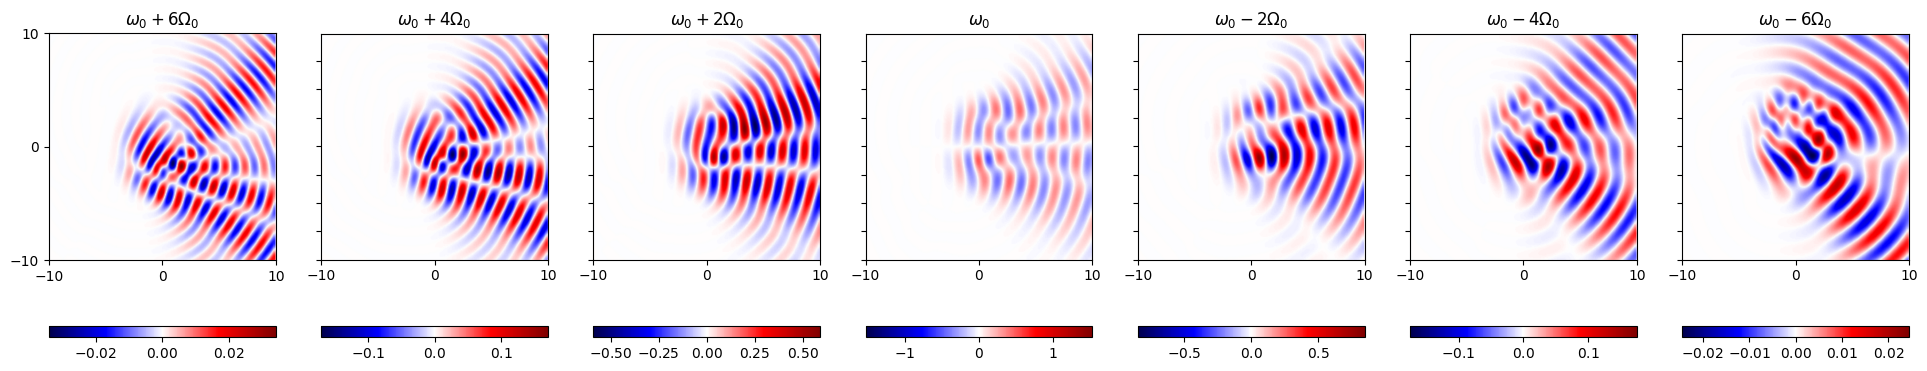

In [14]:
fig = plt.figure(figsize=(24, 4))
gs = gridspec.GridSpec(2, 7, height_ratios=[20, 1], hspace=0.5)
for i, mode in enumerate((-6, -4, -2, 0, 2, 4, 6)):
    ax = fig.add_subplot(gs[0, i])
    ax_cb = fig.add_subplot(gs[1, i])
    draw_mode(fig, ax, ax_cb, corot, mode)
    if i == 0:
        ax.set_yticks([-10, 0, 10])
    else:
        ax.set_yticklabels([])

## Counter-rotating vortex pair

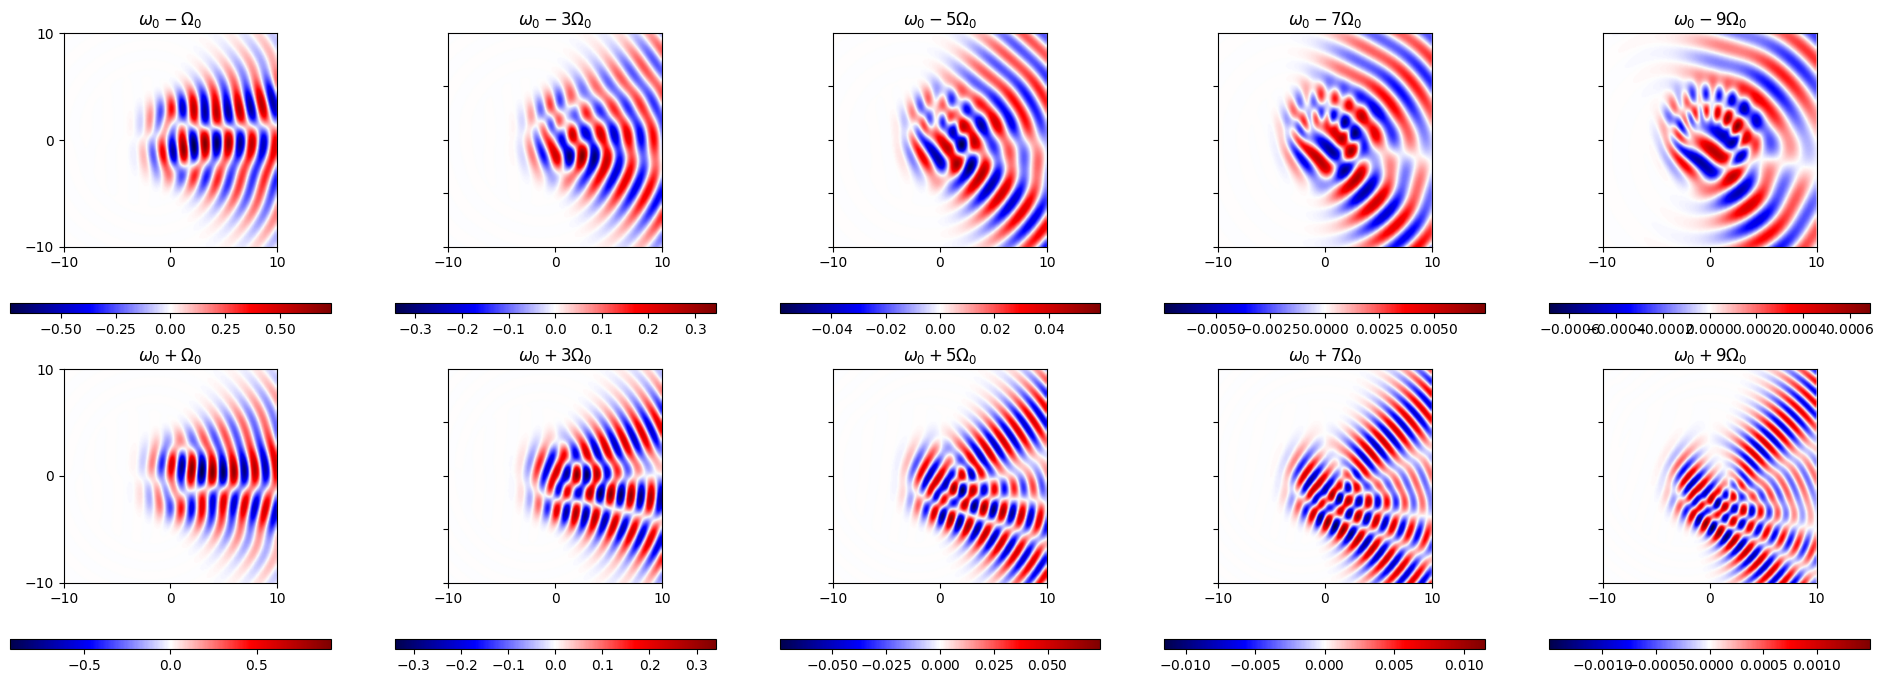

In [15]:
fig = plt.figure(figsize=(24, 8))
gs = gridspec.GridSpec(4, 5, height_ratios=[20, 1, 20, 1], hspace=0.5)
for row, modes in enumerate(((1, 3, 5, 7, 9), (-1, -3, -5, -7, -9))):
    for i, mode in enumerate(modes):
        ax = fig.add_subplot(gs[2 * row, i])
        ax_cb = fig.add_subplot(gs[2 * row + 1, i])
        draw_mode(fig, ax, ax_cb, contra, mode)
        if i == 0:
            ax.set_yticks([-10, 0, 10])
        else:
            ax.set_yticklabels([])

## Fixed-observer spectrum

The final plot samples all computed sidebands at a fixed observer near $(5,0)$.

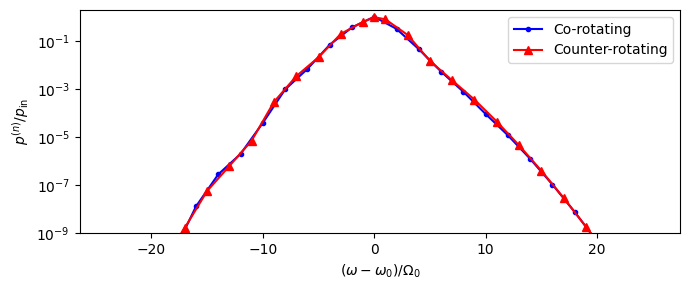

In [16]:
def spectrum_xy(result):
    items = sorted((-mode, amp) for mode, amp in result["spectrum"].items())
    return np.array([x for x, _ in items]), np.array([y for _, y in items])

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(*spectrum_xy(corot), ".-", color="b", label="Co-rotating")
ax.semilogy(*spectrum_xy(contra), "^-", color="r", label="Counter-rotating")
ax.set_xlabel(r"$(\omega-\omega_0)/\Omega_0 $")
ax.set_ylabel(r"$p^{(n)}/p_{\mathrm{in}}$")
ax.set_ylim([1e-9, 2])
ax.legend()
fig.tight_layout()